# Classical MDS from pairwise normalized Levenshtein distances

This notebook computes the full pairwise distance matrix between references and queries and builds a two-dimensional configuration using classical multidimensional scaling. The same MDS construction can also be applied to a pairwise matrix of normalized alignment distances when proteins are the target.

## Inputs

All notebooks use the same FASTA inputs bundled in `sequenceTols`: `example_vertices.fasta` for the three references and `example_queries.fasta` for the query sequences. You can replace those paths in the first code cell with your own FASTA files.

In [1]:
from pathlib import Path
import csv
import math
from pprint import pprint

import matplotlib.pyplot as plt
import numpy as np

REFERENCES_FASTA = Path("example_vertices.fasta")
QUERIES_FASTA = Path("example_queries.fasta")
OUTPUT_PREFIX = Path("notebook_output")


def parse_fasta(path: Path):
    records = []
    header = None
    chunks = []
    with path.open() as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            if line.startswith(">"):
                if header is not None:
                    records.append((header, "".join(chunks).upper()))
                header = line[1:].strip() or f"seq_{len(records) + 1}"
                chunks = []
            else:
                chunks.append(line)
    if header is not None:
        records.append((header, "".join(chunks).upper()))
    if not records:
        raise ValueError(f"No FASTA records found in {path}")
    return records


def normalized_hamming(seq_a: str, seq_b: str) -> float:
    if len(seq_a) != len(seq_b):
        raise ValueError("Hamming distance requires equal-length sequences.")
    if len(seq_a) == 0:
        return 0.0
    mismatches = sum(char_a != char_b for char_a, char_b in zip(seq_a, seq_b))
    return mismatches / len(seq_a)


def levenshtein_distance(seq_a: str, seq_b: str) -> int:
    if len(seq_a) < len(seq_b):
        seq_a, seq_b = seq_b, seq_a
    previous = list(range(len(seq_b) + 1))
    for i, char_a in enumerate(seq_a, start=1):
        current = [i]
        for j, char_b in enumerate(seq_b, start=1):
            insert_cost = current[j - 1] + 1
            delete_cost = previous[j] + 1
            substitute_cost = previous[j - 1] + (char_a != char_b)
            current.append(min(insert_cost, delete_cost, substitute_cost))
        previous = current
    return previous[-1]


def normalized_levenshtein(seq_a: str, seq_b: str) -> float:
    scale = max(len(seq_a), len(seq_b))
    if scale == 0:
        return 0.0
    return levenshtein_distance(seq_a, seq_b) / scale


def affinity_linear(distance: float) -> float:
    return max(0.0, 1.0 - distance)


def close_affinities(affinities):
    affinities = np.asarray(affinities, dtype=float)
    total = float(affinities.sum())
    if total <= 0.0:
        return np.full(3, 1.0 / 3.0)
    return affinities / total


def barycentric_to_cartesian(lambdas):
    vertices = np.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.5, math.sqrt(3.0) / 2.0],
    ])
    return np.asarray(lambdas, dtype=float) @ vertices


def write_csv(path: Path, rows, fieldnames):
    with path.open("w", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


def classical_mds(distance_matrix, n_components=2):
    distance_matrix = np.asarray(distance_matrix, dtype=float)
    n = distance_matrix.shape[0]
    centering = np.eye(n) - np.ones((n, n)) / n
    gram = -0.5 * centering @ (distance_matrix ** 2) @ centering
    eigenvalues, eigenvectors = np.linalg.eigh(gram)
    order = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    positive = np.clip(eigenvalues[:n_components], a_min=0.0, a_max=None)
    return eigenvectors[:, :n_components] @ np.diag(np.sqrt(positive)), eigenvalues


## Mathematical formulation

This notebook uses **all pairwise distances** between references and queries. If
\[
\{S_1,\dots,S_N\}=\{A,B,C,Q_1,\dots,Q_n\},
\]
then the pairwise distance matrix is
\[
\Delta=(\delta_{ij})_{i,j=1}^N,\qquad \delta_{ij}=d_{\mathrm{Lev}}(S_i,S_j).
\]
Classical multidimensional scaling constructs the centered Gram-type matrix
\[
J=I_N-\frac{1}{N}\mathbf{1}\mathbf{1}^\top,
\qquad
B=-\frac12 J\Delta^{\circ 2}J,
\]
where $\Delta^{\circ 2}$ denotes entrywise squaring.

If
\[
B=U\Lambda U^\top
\]
is the eigendecomposition, then the two-dimensional embedding is given by
\[
X_2=U_2\Lambda_2^{1/2},
\]
where $U_2$ contains the first two eigenvectors associated with the largest nonnegative eigenvalues.

## Interpretation and limitations

Unlike the reference-based notebooks, MDS is a **global ordination** method. It tries to preserve the geometry of the whole pairwise distance matrix rather than relative similarity to three anchors.

This usually makes it more appropriate when the goal is to visualize overall structure in the dataset. However:

- it is still a 2D approximation of a potentially high-dimensional distance geometry,
- distortion remains unavoidable when the distances are not close to Euclidean,
- interpretation is global rather than anchor-relative,
- the biological quality of the map depends on the chosen dissimilarity, so for proteins an alignment-based distance matrix may be preferable to Levenshtein distance.

MDS is therefore a method family: the current notebook uses normalized Levenshtein distance, but the same spectral construction can be paired with more biologically informed distances.

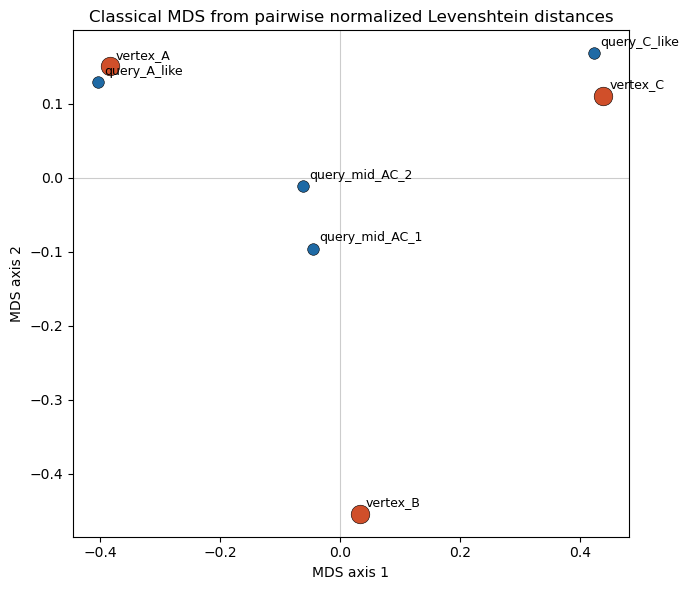

Leading eigenvalues: [ 6.88725384e-01  2.95559618e-01  1.41606332e-01  2.89461185e-02
 -3.08398878e-17]
Saved CSV: notebook_output_mds_coordinates.csv
Saved plot: notebook_output_mds.png
[{'mds_x': -0.3840383407127573,
  'mds_y': 0.15099751112099005,
  'sequence_id': 'vertex_A'},
 {'mds_x': 0.0328842665014306,
  'mds_y': -0.4537550175766839,
  'sequence_id': 'vertex_B'},
 {'mds_x': 0.43849625689419697,
  'mds_y': 0.11145641982804687,
  'sequence_id': 'vertex_C'},
 {'mds_x': -0.4033042976057973,
  'mds_y': 0.12962396462268913,
  'sequence_id': 'query_A_like'},
 {'mds_x': -0.04493163806363605,
  'mds_y': -0.09563341869587613,
  'sequence_id': 'query_mid_AC_1'},
 {'mds_x': -0.06253896221880871,
  'mds_y': -0.011127228945256522,
  'sequence_id': 'query_mid_AC_2'},
 {'mds_x': 0.4234327152053717,
  'mds_y': 0.16843776964609086,
  'sequence_id': 'query_C_like'}]


In [2]:
reference_records = parse_fasta(REFERENCES_FASTA)
query_records = parse_fasta(QUERIES_FASTA)
all_records = reference_records + query_records
labels = [record[0] for record in all_records]
sequences = [record[1] for record in all_records]

n = len(sequences)
distance_matrix = np.zeros((n, n), dtype=float)
for i in range(n):
    for j in range(i + 1, n):
        value = normalized_levenshtein(sequences[i], sequences[j])
        distance_matrix[i, j] = value
        distance_matrix[j, i] = value

coordinates, eigenvalues = classical_mds(distance_matrix, n_components=2)
rows = []
for label, coord in zip(labels, coordinates):
    rows.append({
        "sequence_id": label,
        "mds_x": float(coord[0]),
        "mds_y": float(coord[1]),
    })

output_csv = Path(f"{OUTPUT_PREFIX.name}_mds_coordinates.csv")
write_csv(output_csv, rows, ["sequence_id", "mds_x", "mds_y"])

fig, ax = plt.subplots(figsize=(7, 6))
for idx, (label, coord) in enumerate(zip(labels, coordinates)):
    color = "#d04f2a" if idx < 3 else "#1f6aa5"
    size = 180 if idx < 3 else 70
    ax.scatter(coord[0], coord[1], color=color, s=size, edgecolor="black", linewidth=0.4)
    ax.text(coord[0] + 0.01, coord[1] + 0.01, label, fontsize=9)

ax.set_title("Classical MDS from pairwise normalized Levenshtein distances")
ax.set_xlabel("MDS axis 1")
ax.set_ylabel("MDS axis 2")
ax.axhline(0.0, color="#cccccc", linewidth=0.8)
ax.axvline(0.0, color="#cccccc", linewidth=0.8)
fig.tight_layout()
output_png = Path(f"{OUTPUT_PREFIX.name}_mds.png")
fig.savefig(output_png, dpi=300, bbox_inches="tight")
plt.show()

print("Leading eigenvalues:", eigenvalues[:5])
print(f"Saved CSV: {output_csv}")
print(f"Saved plot: {output_png}")
pprint(rows)
